# Reading The video 

In [1]:
import cv2
import numpy as np
import time

In [5]:
in_path  = 'data/group_11_fixed.mp4'    
out_path = "output/group_11_test_1.mp4"
cap = cv2.VideoCapture(in_path)
if not cap.isOpened():  
    raise IOError(f"Could not open {in_path}")

In [8]:
# === Step 2: Capture background (first few frames) ===
time.sleep(2)  # give camera time to adjust
background_frames = []
for i in range(50):  # capture first 50 frames as background
    ret, frame = cap.read()
    if not ret:
        break
    #frame = np.flip(frame, axis=1)  # optional, if your video is mirrored
    background_frames.append(frame)

In [14]:
background = np.median(background_frames, axis=0).astype(np.uint8)

# === Step 3: Reopen video to process all frames ===
cap = cv2.VideoCapture(in_path)
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# === Step 4: Initialize VideoWriter ===
out = cv2.VideoWriter(out_path, 
                      cv2.VideoWriter_fourcc(*'mp4v'),
                      fps, (width, height))

# === Step 5: Process video frame by frame ===
while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame = np.flip(frame, axis=1)
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    # Green cloak mask
    lower_green = np.array([35, 40, 40])
    upper_green = np.array([85, 255, 255])
    mask = cv2.inRange(hsv, lower_green, upper_green)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((3,3), np.uint8))
    mask = cv2.morphologyEx(mask, cv2.MORPH_DILATE, np.ones((3,3), np.uint8))

    inverse_mask = cv2.bitwise_not(mask)

    # Replace green areas with background
    cloak_removed = cv2.bitwise_and(background, background, mask=mask)
    rest_of_scene = cv2.bitwise_and(frame, frame, mask=inverse_mask)
    final_output = cv2.addWeighted(cloak_removed, 1, rest_of_scene, 1, 0)

    # === Write to output video ===
    out.write(final_output)

    # Optional display
    cv2.imshow('Invisibility Cloak', final_output)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# === Step 6: Release everything ===
cap.release()
out.release()
cv2.destroyAllWindows()

print(f"✅ Saved processed video to: {out_path}")

✅ Saved processed video to: output/group_11_test_1.mp4


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv 


def plot_contours(img , s= 5):
   
   if not np.isin(img, [0, 1]).all():
       print(" image is not binary (should do something about it later)")
   
   SE= cv.getStructuringElement(cv.MORPH_RECT,(s,s))
   dilated_img = cv.dilate(img,SE)
   
   img_contour = dilated_img - img
   
   plt.imshow(img_contour,cmap="gray")
   return img_contour

 image is not binary (should do something about it later)


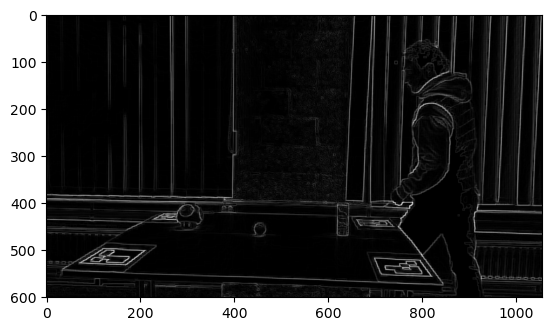

In [8]:
img =cv.imread('oneFrame.png',cv.IMREAD_GRAYSCALE)/255
t = plot_contours(img,s=5)